# Proyecto final integrador · ENSSEX 2022–2023
## Dependencia económica y valoraciones de bienestar en personas que conviven con su pareja

**Universidad Andrés Bello · MCDI500 · Programación para la Ciencia de Datos**  
**Grupo 9:** Guillermo Osorio Zamora y Karla Patricia Pizarro Correa  
**Sumativa 3 · Octubre de 2026**

Recorremos F1–F4 desde los originales verificados hasta las tres visualizaciones y la
respuesta a la pregunta de investigación. Reutilizamos los módulos de preparación,
clases, mediciones y análisis del repositorio. No se requiere ejecutar otro notebook
ni conservar variables de un kernel anterior.

### Contenido
1. [F1: problema, objetivos y alcance](#f1)
2. [Entorno, configuración y fuente](#entorno)
3. [F2: preparación y decisiones](#f2)
4. [F3: arquitectura, equivalencia, pruebas y eficiencia](#f3)
5. [F4: copia interpretable y resultados reproducibles](#f4)
6. [Tres figuras y respuesta a la pregunta](#hallazgos)
7. [Discusión, conclusiones y trazabilidad](#cierre)

Ejecutar **Kernel → Restart Kernel and Run All Cells**, con el kernel
**Python (grupo9-mcdi500)**, y guardar al finalizar. Cada ejecución completa crea
una carpeta nueva en `F4/resultados_locales`, excluida de Git, con los CSV y sus
JSON juntos. Las salidas guardadas del cuaderno muestran resultados agregados;
los microdatos permanecen en los productos locales.

<a id="f1"></a>
## 1. F1: problema, objetivos y alcance

**Pregunta:** ¿Cómo varían la valoración de la vida sexual y el bienestar mental
o emocional percibido según el grado de dependencia económica de la pareja entre
las personas encuestadas en ENSSEX 2022–2023 que conviven con ella?

Nuestro objetivo general es analizar esa variación. Conservamos los cuatro objetivos
específicos de F1: identificar a quienes conviven con su pareja; describir su dependencia
económica; caracterizar ambas valoraciones por dependencia; y comparar sus patrones.

La unidad de análisis es cada persona, no una pareja emparejada. Seleccionamos respuesta
Sí (código 1) en **tiene pareja actualmente (`p81`)** y **convive actualmente con su
pareja (`p83`)**. Describimos la muestra sin ponderación, inferencia poblacional ni
atribución causal. No formulamos una hipótesis causal o un gradiente obligatorio.

| Variable | Papel en la pregunta |
|---|---|
| Dependencia económica de la pareja (`p93`) | Tres grupos: completa, parcial y ninguna |
| Valoración de la vida sexual (`i_6_p9`) | Distribución ordinal de 1 Muy mal a 7 Muy bien |
| Bienestar mental o emocional percibido (`i_2_p9`) | Segunda distribución ordinal, analizada por separado |
| Sexo asignado al nacer (`p1`) | Desagregación complementaria en Hombre y Mujer |

Sexo asignado al nacer (`p1`) es distinto de género declarado (`p3`). No combinamos
las dos valoraciones en un índice ni les asignamos umbrales clínicos. Los valores 2–6
no reciben calificativos inventados. La descripción completa y las reglas provienen
del [esquema de F2](../../F2/docs/esquema_variables_F2.json), construido con las fuentes
documentadas en el [diccionario](../../F2/docs/Diccionario_procesado_F2.md).

<a id="entorno"></a>
## 2. Entorno, configuración y fuente

Requerimos el entorno de `requirements.txt`, el SAV original y su CSV convertido en
`data/raw`, el esquema y la evidencia de conversión. Si faltan originales, seguir la
[guía de obtención](../../docs/datos/Obtencion_y_conversion_ENSSEX.md) y ejecutar desde
Git Bash `python src/convertir_enssex.py --download` antes de abrir el cuaderno.
No descargamos ni reemplazamos originales durante esta ejecución.

La configuración localiza el repositorio desde su raíz o desde `F4/notebooks`.
Las huellas exactas verifican la fuente; para código se registran también huellas
normalizadas a LF, compatibles con los finales de línea de ambos equipos.
Una huella permite detectar cambios respecto de una referencia, no autentica su autoría.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
from importlib.metadata import version
from uuid import uuid4
import sys, os, json, platform, subprocess, inspect
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Code, Image

sys.dont_write_bytecode = True
RAIZ = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'F4/src/analisis_descriptivo.py').is_file()
             and (p / 'F2/docs/esquema_variables_F2.json').is_file()), None)
if RAIZ is None:
    raise FileNotFoundError('Abrir el notebook dentro del repositorio ENSSEX.')
for carpeta in ('F2/src', 'F2/tests', 'F3/src', 'F3/benchmarks', 'F4/src'):
    if str(RAIZ / carpeta) not in sys.path:
        sys.path.insert(0, str(RAIZ / carpeta))
import preparar_enssex as prep
from validar_preparacion_enssex import ejecutar_pruebas
from pipeline_enssex import PipelineENSSEX
from transformadores import Transformador, LimpiadorCodigos, TipificadorCategorias
from faltantes import TratamientoFaltantes
from exportacion_enssex import exportar_resultados_f3, leer_resultados_f3
from medir_diferencia_edad import ejecutar as medir_diferencia
from medir_lectura_sav import ejecutar as medir_lectura
from datos_interpretables import exportar_interpretables, leer_interpretables
from analisis_descriptivo import exportar_analisis, ARCHIVOS_TABLAS

INICIO = datetime.now(timezone.utc)
SEMILLA, REPETICIONES, EJECUCIONES = 42, 5, 5
TAMANOS = (1000, 5000, 8579, 20000, 50000)
SALIDA = RAIZ / 'F4/resultados_locales' / (INICIO.strftime('notebook_%Y%m%d_%H%M%S_') + uuid4().hex[:8])
SALIDA_F3, SALIDA_F4, SALIDA_ANALISIS = SALIDA / 'datos_f3', SALIDA / 'datos_f4', SALIDA / 'analisis'
entorno = {'Python': platform.python_version(), 'Sistema': platform.system(),
           **{p: version(p) for p in ('pandas', 'numpy', 'matplotlib', 'pyreadstat', 'ipykernel')}}
display(pd.Series(entorno, name='Versión').to_frame())
comprobacion_pip = subprocess.run([sys.executable, '-m', 'pip', 'check'],
                                capture_output=True, text=True, encoding='utf-8', errors='replace')
print(comprobacion_pip.stdout, comprobacion_pip.stderr)
comprobacion_pip.check_returncode()
print('Destino local de esta ejecución:', SALIDA.relative_to(RAIZ).as_posix())

,Versión
Python,3.13.15
Sistema,Windows
pandas,3.0.5
numpy,2.5.3
matplotlib,3.11.2
pyreadstat,1.3.6
ipykernel,7.3.0


No broken requirements found.
 
Destino local de esta ejecución: F4/resultados_locales/notebook_20261002_221705_086f70ef


In [2]:
ruta_esquema = RAIZ / 'F2/docs/esquema_variables_F2.json'
ruta_evidencia = RAIZ / 'docs/datos/verificacion_conversion_enssex.json'
esquema = json.loads(ruta_esquema.read_text(encoding='utf-8'))
fuente = json.loads(ruta_evidencia.read_text(encoding='utf-8'))
ruta_csv = RAIZ / 'data/raw' / fuente['csv_file']
ruta_sav = RAIZ / 'data/raw' / fuente['source_file']
for ruta, huella in ((ruta_csv, fuente['csv_sha256']), (ruta_sav, fuente['source_sha256'])):
    if not ruta.is_file():
        raise FileNotFoundError(f'Falta el original: {ruta.relative_to(RAIZ)}. Consultar la guía de obtención.')
    assert prep.sha256_archivo(ruta) == huella, f'Original distinto: {ruta.name}'
protegidos = [ruta_csv, ruta_sav, ruta_esquema, ruta_evidencia, RAIZ / 'requirements.txt']
for carpeta, patron in [('F2/data/processed', '*.csv'), ('F3/data/processed', '*'),
                        ('F4/data/processed', '*'), ('F4/resultados', '*')]:
    protegidos.extend(p for p in (RAIZ / carpeta).rglob(patron) if p.is_file())
for fase in ('F2', 'F3', 'F4'):
    for carpeta in ('src', 'tests', 'benchmarks'):
        protegidos.extend((RAIZ / fase / carpeta).glob('*.py'))
huellas_antes = {p.relative_to(RAIZ).as_posix(): prep.sha256_archivo(p) for p in protegidos}
base = prep.cargar_base(ruta_csv, fuente, esquema)
assert base.shape == (20392, 1126)
huella_base = pd.util.hash_pandas_object(base, index=True).copy()
tipos_base, columnas_base = base.dtypes.copy(), base.columns.copy()
reglas = {v['nombre']: v for v in esquema['variables']}
def etiqueta(codigo):
    return f"{reglas[codigo]['nombre_legible']} ({codigo})"
def describir(tabla):
    copia = tabla.copy()
    if 'variable' in copia:
        copia['variable'] = copia['variable'].map(lambda v: etiqueta(v) if v in reglas else v)
    return copia.rename(columns={c: etiqueta(c) for c in copia.columns if c in reglas})
display(pd.DataFrame([{'Archivo': ruta_csv.name, 'SHA-256': fuente['csv_sha256']},
                      {'Archivo': ruta_sav.name, 'SHA-256': fuente['source_sha256']}]))
display(pd.DataFrame([{'Variable': etiqueta(v['nombre']), 'Descripción': v['descripcion'],
                      'Tipo analítico': v['tipo']} for v in esquema['variables']]))
print('Fuente verificada: 20.392 personas y 1.126 columnas.')

,Archivo,SHA-256
0,20241205_enssex_desde_sav.csv,75393ce321f5151fbfd7846034158aabcbe448e82c76fa...
1,20241205_enssex_data.sav,0f4218b9553600dfd44e6b1f78d376b040a0e6f0d85445...


,Variable,Descripción,Tipo analítico
0,Dependencia económica de la pareja (p93),¿Diría que usted depende económicamente de su ...,ordinal
1,Valoración de la vida sexual (i_6_p9),P9: valorar de 1 a 7 cómo se siente en distint...,ordinal
2,Bienestar mental o emocional percibido (i_2_p9),P9: valorar de 1 a 7 cómo se siente en distint...,ordinal
3,Edad de la persona encuestada (p4),¿Qué edad tiene? (años).,discreta
4,Sexo asignado al nacer (p1),¿Cuál es su sexo asignado al nacer?,nominal
5,Género declarado (p3),¿Cuál es el género con el que usted se identif...,nominal
6,Nivel educacional (p5),¿Cuál es su nivel educacional más alto alcanza...,nominal
7,Región (region),Región registrada en la base; no es una pregun...,nominal
8,Estado conyugal o civil (p7),¿Cuál es su estado conyugal o civil actual?,nominal
9,Ingreso relativo respecto de la pareja (p92),"Comparando con su pareja actual, el ingreso ec...",nominal


Fuente verificada: 20.392 personas y 1.126 columnas.


<a id="f2"></a>
## 3. F2: preparación y decisiones

Reproducimos las funciones de F2: selección, recodificación por variable, tipos
categóricos y enteros anulables, diferencia de edad y matriz nominal. La diferencia
resta edad de la pareja (`p91`) a edad de la persona (`p4`). Conservamos ausencias,
extremos y las categorías originales; no aplicamos imputación ni eliminación global.

No calculamos duración de convivencia: las fuentes no precisan qué evento representa
la fecha registrada (`fecha`). Tampoco aplicamos escalamiento numérico: las distribuciones
por categorías no lo requieren. La matriz nominal es un producto auxiliar y no sustituye
la tabla interpretable para comunicar resultados.

In [3]:
seleccion, flujo = prep.seleccionar_convivientes(base, esquema)
limpia, limpieza = prep.limpiar_codigos(seleccion, esquema)
tipificada = prep.tipificar_categorias(limpia, esquema)
principal_f2 = prep.construir_derivadas(tipificada)
nominales_f2 = prep.codificar_nominales(principal_f2, esquema)
validaciones_f2 = prep.validar_resultado(seleccion, principal_f2, nominales_f2, esquema)
assert seleccion.shape == (8579, 19)
assert principal_f2.shape == (8579, 20) and nominales_f2.shape == (8579, 65)
assert len(validaciones_f2) == 130 and validaciones_f2['resultado'].eq('OK').all()
assert int(limpieza['NS_NR_a_faltante'].sum()) == 883
assert 'anios_convivencia_aprox' not in principal_f2
display(flujo)
display(describir(limpieza))
display(pd.DataFrame([{'Producto': 'Selección de convivientes', 'Filas': len(seleccion), 'Columnas': 19},
                      {'Producto': 'Principal F2', 'Filas': len(principal_f2), 'Columnas': 20},
                      {'Producto': 'Nominal auxiliar F2', 'Filas': len(nominales_f2), 'Columnas': 65}]))
print('OK: 883 códigos recodificados y 130 comprobaciones; sin imputación ni descarte global.')

,etapa,filas,excluidas_en_paso
0,Base completa,20392,0
1,Tiene pareja (p81=1),11239,9153
2,Además convive (p83=1),8579,2660


,variable,vacios_originales,NS_NR_a_faltante,faltantes_despues,filas_eliminadas
0,Dependencia económica de la pareja (p93),0,77,77,0
1,Valoración de la vida sexual (i_6_p9),0,105,105,0
2,Bienestar mental o emocional percibido (i_2_p9),0,11,11,0
3,Edad de la persona encuestada (p4),0,0,0,0
4,Sexo asignado al nacer (p1),0,0,0,0
5,Género declarado (p3),0,3,3,0
6,Nivel educacional (p5),0,0,0,0
7,Región (region),0,0,0,0
8,Estado conyugal o civil (p7),0,5,5,0
9,Ingreso relativo respecto de la pareja (p92),0,170,170,0


,Producto,Filas,Columnas
0,Selección de convivientes,8579,19
1,Principal F2,8579,20
2,Nominal auxiliar F2,8579,65


OK: 883 códigos recodificados y 130 comprobaciones; sin imputación ni descarte global.


<a id="f3"></a>
## 4. F3: arquitectura y equivalencia con F2

`PipelineENSSEX` compone `LimpiadorCodigos`, `TratamientoFaltantes` y
`TipificadorCategorias`. Estas clases heredan de `Transformador` y responden a
`ajustar(...).transformar(...)`: la misma llamada ejecuta operaciones distintas
(polimorfismo). La configuración y las salidas se protegen con copias; los atributos
internos usan la convención de guion bajo, no una barrera de acceso.

`TratamientoFaltantes` recibe estrategias intercambiables. En el producto final
usamos conservación: los escenarios exploratorios de imputación de F3 no alimentan
las figuras. Elegimos división funcional y composición porque el flujo es tabular;
no añadimos recursividad sin necesidad. El [notebook de F3](../../F3/notebooks/F3_Nucleo_algoritmico_ENSSEX.ipynb)
conserva el desarrollo detallado de clases y los 14 escenarios exploratorios.

Mostramos el método real y verificamos que la implementación mediante clases conserva
los productos de F2. La igualdad entre implementaciones se complementa con casos de
resultados conocidos; no sustituye la justificación de las reglas del dominio.

In [4]:
display(Code(inspect.getsource(PipelineENSSEX.ejecutar), language='python'))
resultados_f3 = PipelineENSSEX(esquema).ejecutar(base)
referencias_f2 = {'seleccion': seleccion, 'flujo_seleccion': flujo, 'limpia': limpia,
                 'resumen_limpieza': limpieza, 'tipificada': tipificada,
                 'principal': principal_f2, 'nominales': nominales_f2}
for nombre, tabla in referencias_f2.items():
    pd.testing.assert_frame_equal(resultados_f3[nombre], tabla, check_exact=True)
assert len(resultados_f3['validaciones']) == 130
assert resultados_f3['validaciones']['resultado'].eq('OK').all()
assert resultados_f3['resumen_faltantes']['imputados'].eq(0).all()
assert resultados_f3['resumen_faltantes']['filas_excluidas'].eq(0).all()
display(pd.DataFrame({'Producto comparado': list(referencias_f2), 'Igualdad exacta': 'OK'}))
display(describir(resultados_f3['resumen_faltantes']))

def ejecutar(self, base):
        """Recibe la base original cargada y devuelve productos y evidencia.

Rechaza entradas incorrectas antes de devolver resultados. No descarga, exporta
ni altera archivos. Las dimensiones esperadas del conjunto real se comprueban
en las pruebas; también admite muestras pequeñas para verificar casos límite.
"""
        if not isinstance(base, pd.DataFrame):
            raise TypeError('La base debe ser un DataFrame de pandas.')
        if not base.index.is_unique:
            raise ValueError('La base debe tener un índice único.')
        seleccion, flujo = seleccionar_convivientes(base, self._esquema)
        limpiador = LimpiadorCodigos(self._esquema)
        tratamientos = [
            TratamientoFaltantes(self._esquema, nombre, conservar_faltantes, seleccion)
            for nombre in self._esquema['centrales']
        ]
        tipificador = TipificadorCategorias(self._esquema)

        # Composición: el pipeline utiliza objetos con tareas específicas.
        etapas = [limpiador] + tratamientos + [tipificador]
        tabla = seleccion
        limpia = None
        for etapa in etapas:
            # Polimorfismo: la misma llamada ejecuta la operación de cada hija.
            tabla = etapa.ajustar(tabla).transformar(tabla)
            if etapa is limpiador:
                limpia = tabla.copy(deep=True)

        tipificada = tabla
        principal = construir_derivadas(tipificada)
        nominales = codificar_nominales(principal, self._esquema)
        validaciones = validar_resultado(seleccion, principal, nominales, self._esquema)
        resultados = {
            'seleccion': seleccion,
            'limpia': limpia,
            'tipificada': tipificada,
            'principal': principal,
            'nominales': nominales,
            'flujo_seleccion': flujo,
            'resumen_limpieza': limpiador.resumen(),
            'resumen_faltantes': pd.concat(
                [objeto.resumen() for objeto in tratamientos], ignore_index=True
            ),
            'disponibilidad': disponibilidad_analisis(limpia, self._esquema),
            'validaciones': validaciones,
        }
        return {nombre: tabla.copy(deep=True) for nombre, tabla in resultados.items()}

,Producto comparado,Igualdad exacta
0,seleccion,OK
1,flujo_seleccion,OK
2,limpia,OK
3,resumen_limpieza,OK
4,tipificada,OK
5,principal,OK
6,nominales,OK


,variable,alternativa,filas_entrada,filas,filas_excluidas,elegibles,vacios_originales_protegidos,faltantes,imputados,valores_fraccionarios,fuera_de_categorias,varianza_codigos,cambio_varianza_pct
0,Dependencia económica de la pareja (p93),Conservar faltantes,8579,8579,0,77,0,77,0,0,0,0.704055,0.0
1,Valoración de la vida sexual (i_6_p9),Conservar faltantes,8579,8579,0,105,0,105,0,0,0,2.422101,0.0
2,Bienestar mental o emocional percibido (i_2_p9),Conservar faltantes,8579,8579,0,11,0,11,0,0,0,1.599574,0.0


### Pruebas normales, límites y errores

Ejecutamos los casos controlados de F2 y los nueve scripts de F3–F4. Incluyen
entradas vacías, una persona, categorías sin observaciones, ausencias superpuestas,
categorías inesperadas, folios duplicados, uso incorrecto del estado, sobrescritura
y alteración de productos. Las excepciones esperadas se comprueban dentro de las
pruebas; cualquier fallo real detiene este cuaderno. No descargan ni reemplazan originales.

In [5]:
pruebas_f2 = ejecutar_pruebas(esquema)
display(pruebas_f2)
scripts = [f'F3/tests/{n}.py' for n in (
    'validar_transformadores', 'validar_faltantes', 'validar_pipeline',
    'validar_exportacion', 'validar_medicion_lectura', 'validar_diferencia_edad',
    'validar_medicion_algoritmos')]
scripts += ['F4/tests/validar_interpretables.py', 'F4/tests/validar_analisis.py']
registros_pruebas = []
for script in scripts:
    proceso = subprocess.run([sys.executable, str(RAIZ / script)], cwd=RAIZ,
                             env={**os.environ, 'PYTHONIOENCODING': 'utf-8'},
                             capture_output=True, text=True, encoding='utf-8', errors='replace')
    print(script, '\n', proceso.stdout, proceso.stderr)
    registros_pruebas.append({'script': script, 'codigo_salida': proceso.returncode,
                              'stdout': proceso.stdout, 'stderr': proceso.stderr})
    proceso.check_returncode()
assert len(registros_pruebas) == 9
print('OK: casos controlados F2 y nueve scripts F3–F4 completados.')

,caso,resultado
0,Región 8 y 9 son válidas,OK
1,"Estado civil 8 válido, 88/99 ausentes",OK
2,"Ingreso relativo 6 válido, 8/9 ausentes",OK
3,Edad de pareja 99 válida; 999 es NS/NR,OK
4,"Género 7, 8 y 9 son no respuesta",OK
5,Año 9999 es no respuesta,OK
6,"Escala 1–7 admite extremos, recodifica 9",OK
7,Escala 1–7 rechaza código 8,OK
8,Edad rechaza texto inesperado,OK
9,Edad rechaza valores fraccionarios,OK


F3/tests/validar_transformadores.py 
 OK: Impide transformar o consultar resultados antes de tiempo
OK: Caso normal: códigos, ausencias, tipos e índice correctos
OK: Las copias protegen la entrada y el resumen interno
OK: Cambiar el esquema externo no altera las reglas del objeto
OK: Límites: una fila, sin faltantes y todos faltantes
OK: Rechaza columnas ausentes o duplicadas, vacío, tipo y código inválidos
OK: Un ajuste fallido deshabilita el objeto; un ajuste válido permite recuperarlo
OK: La clase base exige que la clase hija aporte la operación
OK: categorías ordinales y nominales correctas.
OK: valores, faltantes y entrada conservados.
OK: rechaza categorías desconocidas y uso antes de ajustar.
OK: selección real de 8,579 personas y 19 columnas.
OK: valores, ausencias, tipos, orden y resumen idénticos a la limpieza de F2.
OK: tipificación real de 8.579 personas y 19 columnas idéntica a F2.
OK: categorías y orden coinciden con el esquema; códigos, faltantes y columnas no categórica

F3/tests/validar_faltantes.py 
 OK: cinco estrategias, resultados conocidos, copias y control de estado.
OK: vacíos originales protegidos; sin grupo o sin donantes no se imputa por grupo.
OK: límites, configuración protegida y rechazo de entradas no correspondientes.
OK: 14 escenarios equivalentes a F2 en valores y resumen; 8.579 personas y 19 columnas.
OK: conservar faltantes mantiene tabla, tipos e índice; ninguna entrada fue modificada.
Alcance: escenarios descriptivos; no se generan ni reemplazan productos de datos.
 


F3/tests/validar_pipeline.py 
 OK: filtros, categorías, derivada, ausencias y matriz nominal en ejemplos conocidos.
OK: una persona, centrales ausentes, esquema protegido y ejecuciones independientes.
OK: errores de entrada rechazados y ejecución válida después de los errores.
OK: productos e intermedios exactamente equivalentes a F2.
OK: 8.579 personas, 20 columnas principales y 65 columnas nominales.
OK: 130 comprobaciones; cero imputaciones y exclusiones por faltantes.
OK: base de entrada intacta; no se exportaron archivos.
 


F3/tests/validar_exportacion.py 
 OK: relectura exacta de valores, tipos, categorías, orden, fechas y faltantes.
OK: folios con ceros iniciales, una persona y categorías sin observaciones.
OK: rechaza sobrescritura, productos inválidos y cambios en los bytes del CSV.
OK: rechaza categorías desconocidas e indicadores fuera de 0/1 antes de convertirlos.
OK: ENSSEX real recuperado exactamente: 8.579 personas, 20 columnas y matriz de 65.
OK: dos exportaciones idénticas byte a byte en este entorno; 130 comprobaciones previas.
OK: tablas recibidas, base original y CSV de F2 intactos. Solo destinos temporales.
 


F3/tests/validar_medicion_lectura.py 
 OK: valores, tipos, orden solicitado, texto, ausencias y metadatos equivalentes.
OK: códigos de faltantes SPSS conservados; detecta valores o etiquetas distintos.
OK: configuración inválida rechazada; no interfiere con rastreo externo de memoria.
OK: repeticiones registradas, orden alternado y dos métricas de memoria separadas.
OK: SAV de prueba intacto; no se exige que una alternativa gane en cada equipo.
 


F3/tests/validar_diferencia_edad.py 
 OK: diferencias conocidas, signo, cero, faltantes, índice y tipo Int64.
OK: vacío, una fila, sin faltantes, todos faltantes y copias independientes.
OK: rechaza estructura o tipos incorrectos; exige edades previamente limpias.
OK: ambas alternativas coinciden exactamente con F2 para 8.579 personas.
OK: valores, faltantes, nombre, tipo e índice conservados; entrada intacta.
Alcance: equivalencia de algoritmos; tiempos y memoria se medirán por separado.
 


F3/tests/validar_medicion_algoritmos.py 
 OK: muestras reproducibles con reemplazo; no amplían la población del estudio.
OK: repeticiones, orden alternado, faltantes y dos métricas de memoria por tamaño.
OK: una diferencia entre alternativas impide iniciar las mediciones.
OK: configuración inválida rechazada; rastreo externo protegido; entrada intacta.
 


F4/tests/validar_interpretables.py 
 OK: códigos intactos, etiquetas exactas, categorías no observadas y orden ordinal.
OK: una persona, todas las centrales ausentes y tabla vacía, sin modificar entradas.
OK: rechaza folios duplicados, códigos inesperados y etiquetas ambiguas o incompletas.
OK: relectura exacta, rechazo de sobrescritura y detección de CSV o etiquetas alteradas.
 


F4/tests/validar_analisis.py 
 OK: denominadores específicos, ausencias superpuestas y base común calculados manualmente.
OK: categorías con cero, grupos sin base, tabla vacía y una persona; entradas intactas.
OK: rechazo de folios duplicados, categorías inesperadas y orden ordinal incorrecto.
OK: sexo asignado al nacer (p1), ausencias conservadas y conciliación exacta con el total.
OK: gráficos coherentes con tablas, escala común y tratamiento de grupos sin base.
OK: exportación reproducible, relectura de tablas y rechazo de sobrescritura o entrada alterada.
 
OK: casos controlados F2 y nueve scripts F3–F4 completados.


### Eficiencia: equivalencia antes de medir

Repetimos las mediciones de F3 con `timeit` y `tracemalloc`, separando tiempo y
memoria. Comparamos bucle y resta por columnas para la diferencia entre edad de la
persona (`p4`) y edad de la pareja (`p91`), con cinco repeticiones de cinco ejecuciones.
Las muestras con reemplazo y semilla 42 tienen 1.000, 5.000, 8.579, 20.000 y 50.000 filas;
son cargas de rendimiento, no personas adicionales. Se comprueba igualdad antes de medir.

El tiempo incluye validación, resta y construcción de la serie; excluye carga,
preparación y verificación. La memoria se mide en otra ejecución y corresponde al
máximo rastreado, no a toda la RAM. Guardamos todas las repeticiones y presentamos
el menor tiempo por ejecución, que no es un promedio ni un intervalo de confianza.

In [6]:
medicion_edades = medir_diferencia(TAMANOS, REPETICIONES, EJECUCIONES, SEMILLA)
tabla_tiempos = pd.DataFrame([
    {'Filas': m['filas'], 'Alternativa': nombre,
     'Menor tiempo (ms)': v['menor_segundos'] * 1000,
     'Máximo de memoria rastreada (MiB)': v['maximo_rastreado_bytes'] / 2**20,
     'Serie devuelta (MiB)': v['serie_devuelta_bytes'] / 2**20,
     'Equivalencia': m['equivalencia']}
    for m in medicion_edades['mediciones'] for nombre, v in m['resultados'].items()])
display(tabla_tiempos.round(5))
tiempos = tabla_tiempos.pivot(index='Filas', columns='Alternativa', values='Menor tiempo (ms)')
razon = tiempos.loc[8579, 'bucle'] / tiempos.loc[8579, 'columnas']
display(Markdown(f'En la muestra de rendimiento de 8.579 filas, el cociente de tiempos '
                 f'bucle/columnas es **{razon:.3f}**. Mayor que 1 favorece columnas; '
                 'menor que 1 favorece bucle. Conservamos la medición obtenida.'))

Equivalencia con F2 comprobada; midiendo muestras de rendimiento...


,Filas,Alternativa,Menor tiempo (ms),Máximo de memoria rastreada (MiB),Serie devuelta (MiB),Equivalencia
0,1000,bucle,1.27892,0.04974,0.00871,OK
1,1000,columnas,0.58436,0.01656,0.00871,OK
2,5000,bucle,1.89224,0.23763,0.04304,OK
3,5000,columnas,0.19430,0.05090,0.04304,OK
4,8579,bucle,3.15374,0.40981,0.07376,OK
5,8579,columnas,0.18300,0.08161,0.07376,OK
6,20000,bucle,8.57182,0.94920,0.17179,OK
7,20000,columnas,0.27898,0.17964,0.17179,OK
8,50000,bucle,20.89518,2.38101,0.42928,OK
9,50000,columnas,0.62636,0.43713,0.42928,OK


En la muestra de rendimiento de 8.579 filas, el cociente de tiempos bucle/columnas es **17.234**. Mayor que 1 favorece columnas; menor que 1 favorece bucle. Conservamos la medición obtenida.

Ambas alternativas tienen tiempo O(n) y espacio O(n), incluida la salida. Mantenemos
la resta por columnas ya utilizada en F2 por claridad y conservación de tipos y ausencias.
La ventaja temporal observada no implica una mejora de orden asintótico; los costos
fijos impiden deducir O(1) de una curva casi plana. El pipeline completo conserva
intermedios para trazabilidad, por lo que consume memoria adicional.

También comparamos lectura SAV completa y selección de 19 columnas frente a lectura
selectiva con `usecols`. Son cinco repeticiones de una lectura, después de comprobar
igualdad de datos y metadatos. La caché ya está caliente. Este experimento no cambia
el cargador CSV del flujo principal ni demuestra una aceleración de todo el pipeline.

In [7]:
medicion_sav = medir_lectura(REPETICIONES, 1)
display(pd.DataFrame([
    {'Alternativa': n, 'Menor tiempo (s)': v['menor_segundos'],
     'Máximo de memoria rastreada (MiB)': v['maximo_rastreado_bytes'] / 2**20,
     'Tabla devuelta (MiB)': v['tabla_devuelta_bytes'] / 2**20}
    for n, v in medicion_sav['resultados'].items()]).round(5))
assert medicion_sav['equivalencia'] == 'OK'
completa = medicion_sav['resultados']['completo_y_seleccion']
selectiva = medicion_sav['resultados']['solo_columnas']
display(Markdown(f"El cociente de tiempos completa/selectiva es **{completa['menor_segundos'] / selectiva['menor_segundos']:.3f}**. "
                 'La lectura selectiva reduce las columnas materializadas de 1.126 a 19; '
                 'su costo de acceso también depende del formato y la biblioteca. '
                 'No suponemos una reducción proporcional de los bytes leídos.'))

SAV verificado. Comparando valores y metadatos antes de medir...


,Alternativa,Menor tiempo (s),Máximo de memoria rastreada (MiB),Tabla devuelta (MiB)
0,completo_y_seleccion,2.27707,671.40314,3.94244
1,solo_columnas,0.46160,13.14595,3.94244


El cociente de tiempos completa/selectiva es **4.933**. La lectura selectiva reduce las columnas materializadas de 1.126 a 19; su costo de acceso también depende del formato y la biblioteca. No suponemos una reducción proporcional de los bytes leídos.

<a id="f4"></a>
## 5. F4: copia interpretable y exportación verificada

Exportamos los dos CSV de F3 junto con su manifiesto, los releemos con restauración
de tipos y verificamos igualdad exacta. F4 conserva las 20 columnas principales y
agrega 14 columnas de etiquetas. El CSV interpretable y su JSON permanecen juntos.
Las rutas están bajo el destino local de esta ejecución; no se reemplazan productos
previos. Para repetir todo, reiniciar el kernel y ejecutar todas las celdas.

In [8]:
manifiesto_f3 = exportar_resultados_f3(resultados_f3, SALIDA_F3, esquema)
recuperadas_f3 = leer_resultados_f3(SALIDA_F3)
for nombre in ('principal', 'nominales'):
    pd.testing.assert_frame_equal(resultados_f3[nombre].reset_index(drop=True),
                                  recuperadas_f3[nombre], check_exact=True)
registro_f4 = exportar_interpretables(recuperadas_f3['principal'], esquema, SALIDA_F3, SALIDA_F4)
interpretable = leer_interpretables(SALIDA_F4)
assert interpretable.shape == (8579, 34)
pd.testing.assert_frame_equal(interpretable[principal_f2.columns],
                              principal_f2.reset_index(drop=True), check_exact=True)
display(pd.DataFrame([{'Variable': etiqueta(c), 'Respuestas ausentes': int(interpretable[c].isna().sum())}
                      for c in esquema['centrales']]))
print('OK: relectura exacta; 8.579 personas, 20 columnas conservadas y 14 columnas de etiquetas.')

,Variable,Respuestas ausentes
0,Dependencia económica de la pareja (p93),77
1,Valoración de la vida sexual (i_6_p9),105
2,Bienestar mental o emocional percibido (i_2_p9),11


OK: relectura exacta; 8.579 personas, 20 columnas conservadas y 14 columnas de etiquetas.


In [9]:
resumen = exportar_analisis(SALIDA_F4, SALIDA_ANALISIS)
comparacion_tablas = []
for nombre in ARCHIVOS_TABLAS.values():
    publicada = pd.read_csv(RAIZ / 'F4/resultados' / nombre, sep=';', encoding='utf-8-sig')
    reproducida = pd.read_csv(SALIDA_ANALISIS / nombre, sep=';', encoding='utf-8-sig')
    pd.testing.assert_frame_equal(publicada, reproducida, check_exact=False, rtol=1e-12, atol=1e-12)
    comparacion_tablas.append({'Tabla': nombre, 'Coincidencia de contenido': 'OK'})
referencia = json.loads((RAIZ / 'F4/resultados/resumen_analitico.json').read_text(encoding='utf-8'))
for clave in ('personas', 'dependencia', 'comparaciones', 'base_comun', 'por_sexo', 'variables', 'metodologia'):
    assert resumen[clave] == referencia[clave], f'Diferencia analítica: {clave}'
assert len(list(SALIDA_ANALISIS.glob('*.csv'))) == 8
assert len(list(SALIDA_ANALISIS.glob('*.png'))) == 3
assert len(list(SALIDA_ANALISIS.glob('*.svg'))) == 3
display(pd.DataFrame(comparacion_tablas))
print('OK: ocho tablas y resultados analíticos coinciden con la referencia del PR #14.')

,Tabla,Coincidencia de contenido
0,dependencia_economica.csv,OK
1,denominadores.csv,OK
2,valoracion_vida_sexual.csv,OK
3,bienestar_mental_emocional.csv,OK
4,dependencia_economica_por_sexo.csv,OK
5,denominadores_por_sexo.csv,OK
6,valoracion_vida_sexual_por_sexo.csv,OK
7,bienestar_mental_emocional_por_sexo.csv,OK


OK: ocho tablas y resultados analíticos coinciden con la referencia del PR #14.


### Denominadores y ausencias

Cada valoración usa respuestas válidas de dependencia y de esa dimensión. No
descartamos una persona por tener ausente la otra valoración. En valoración de la
vida sexual (`i_6_p9`), descontamos la superposición de dos ausencias:
8.579 − 77 − 105 + 2 = 8.399. En bienestar mental o emocional percibido (`i_2_p9`):
8.579 − 77 − 11 = 8.491. La base común de las tres respuestas, 8.392, se informa como
referencia y no se usa como denominador de las figuras por dimensión.

Al desagregar por sexo asignado al nacer (`p1`), cada porcentaje usa las respuestas
válidas de su combinación de sexo y dependencia económica de la pareja (`p93`).
Las categorías con cero conservan 0% cuando hay base; un grupo sin base tiene
porcentaje no calculable. No convertimos ausencias en respuestas sustantivas.

In [10]:
assert resumen['personas'] == 8579 and resumen['dependencia']['validos'] == 8502
assert resumen['comparaciones']['i_6_p9']['base_comparacion'] == 8399
assert resumen['comparaciones']['i_2_p9']['base_comparacion'] == 8491
assert resumen['base_comun']['personas'] == 8392
display(pd.DataFrame(resumen['dependencia']['distribucion']).round(2))
display(pd.DataFrame([f for v in resumen['comparaciones'].values() for f in v['denominadores']]).round(2))
tabla_sexo = pd.read_csv(SALIDA_ANALISIS / 'denominadores_por_sexo.csv', sep=';', encoding='utf-8-sig')
display(tabla_sexo[tabla_sexo['sexo'].ne('Sin respuesta')].round(2))
display(pd.DataFrame([{'Variable': resumen['por_sexo']['variable'], 'Categoría': g['sexo'],
                      'Personas': g['personas']} for g in resumen['por_sexo']['grupos']]))
print('Sin respuesta en sexo asignado al nacer (p1):', resumen['por_sexo']['sin_respuesta']['personas'])

,variable,codigo_grupo,grupo,personas,denominador,porcentaje
0,Dependencia económica de la pareja (p93),1,"Sí, completamente",2197,8502,25.84
1,Dependencia económica de la pareja (p93),2,"Sí, en parte",1987,8502,23.37
2,Dependencia económica de la pareja (p93),3,No,4318,8502,50.79


,variable,agrupacion,codigo_grupo,grupo,total_grupo,validos,ausentes,porcentaje_ausentes_grupo
0,Valoración de la vida sexual (i_6_p9),Dependencia económica de la pareja (p93),1,"Sí, completamente",2197,2170,27,1.23
1,Valoración de la vida sexual (i_6_p9),Dependencia económica de la pareja (p93),2,"Sí, en parte",1987,1960,27,1.36
2,Valoración de la vida sexual (i_6_p9),Dependencia económica de la pareja (p93),3,No,4318,4269,49,1.13
3,Bienestar mental o emocional percibido (i_2_p9),Dependencia económica de la pareja (p93),1,"Sí, completamente",2197,2194,3,0.14
4,Bienestar mental o emocional percibido (i_2_p9),Dependencia económica de la pareja (p93),2,"Sí, en parte",1987,1986,1,0.05
5,Bienestar mental o emocional percibido (i_2_p9),Dependencia económica de la pareja (p93),3,No,4318,4311,7,0.16


,desagregacion,codigo_sexo,sexo,variable,agrupacion,codigo_grupo,grupo,total_grupo,validos,ausentes,porcentaje_ausentes_grupo
0,Sexo asignado al nacer (p1),1.0,Hombre,Valoración de la vida sexual (i_6_p9),Dependencia económica de la pareja (p93),1,"Sí, completamente",120,118,2,1.67
1,Sexo asignado al nacer (p1),1.0,Hombre,Valoración de la vida sexual (i_6_p9),Dependencia económica de la pareja (p93),2,"Sí, en parte",337,335,2,0.59
2,Sexo asignado al nacer (p1),1.0,Hombre,Valoración de la vida sexual (i_6_p9),Dependencia económica de la pareja (p93),3,No,2336,2320,16,0.68
3,Sexo asignado al nacer (p1),1.0,Hombre,Bienestar mental o emocional percibido (i_2_p9),Dependencia económica de la pareja (p93),1,"Sí, completamente",120,120,0,0.00
4,Sexo asignado al nacer (p1),1.0,Hombre,Bienestar mental o emocional percibido (i_2_p9),Dependencia económica de la pareja (p93),2,"Sí, en parte",337,337,0,0.00
5,Sexo asignado al nacer (p1),1.0,Hombre,Bienestar mental o emocional percibido (i_2_p9),Dependencia económica de la pareja (p93),3,No,2336,2334,2,0.09
6,Sexo asignado al nacer (p1),2.0,Mujer,Valoración de la vida sexual (i_6_p9),Dependencia económica de la pareja (p93),1,"Sí, completamente",2077,2052,25,1.20
7,Sexo asignado al nacer (p1),2.0,Mujer,Valoración de la vida sexual (i_6_p9),Dependencia económica de la pareja (p93),2,"Sí, en parte",1650,1625,25,1.52
8,Sexo asignado al nacer (p1),2.0,Mujer,Valoración de la vida sexual (i_6_p9),Dependencia económica de la pareja (p93),3,No,1982,1949,33,1.66
9,Sexo asignado al nacer (p1),2.0,Mujer,Bienestar mental o emocional percibido (i_2_p9),Dependencia económica de la pareja (p93),1,"Sí, completamente",2077,2074,3,0.14


,Variable,Categoría,Personas
0,Sexo asignado al nacer (p1),Hombre,2822
1,Sexo asignado al nacer (p1),Mujer,5757


Sin respuesta en sexo asignado al nacer (p1): 0


<a id="hallazgos"></a>
## 6. Tres visualizaciones y hallazgos

Las imágenes siguientes provienen de esta ejecución, no de una copia de las figuras
publicadas. Conservamos las siete categorías y los denominadores visibles. Los mapas
de calor usan una escala común; no normalizamos el color de cada panel por separado.

### Figura 1. Dependencia económica de la pareja (`p93`)

Responde al objetivo de describir la composición del grupo seleccionado. Entre las
8.502 respuestas válidas, 50,79% no depende de su pareja, 25,84% depende completamente
y 23,37% en parte. Las 77 ausencias se informan aparte. Los grupos tienen tamaños
distintos; por eso las valoraciones se comparan con porcentajes internos a cada grupo.

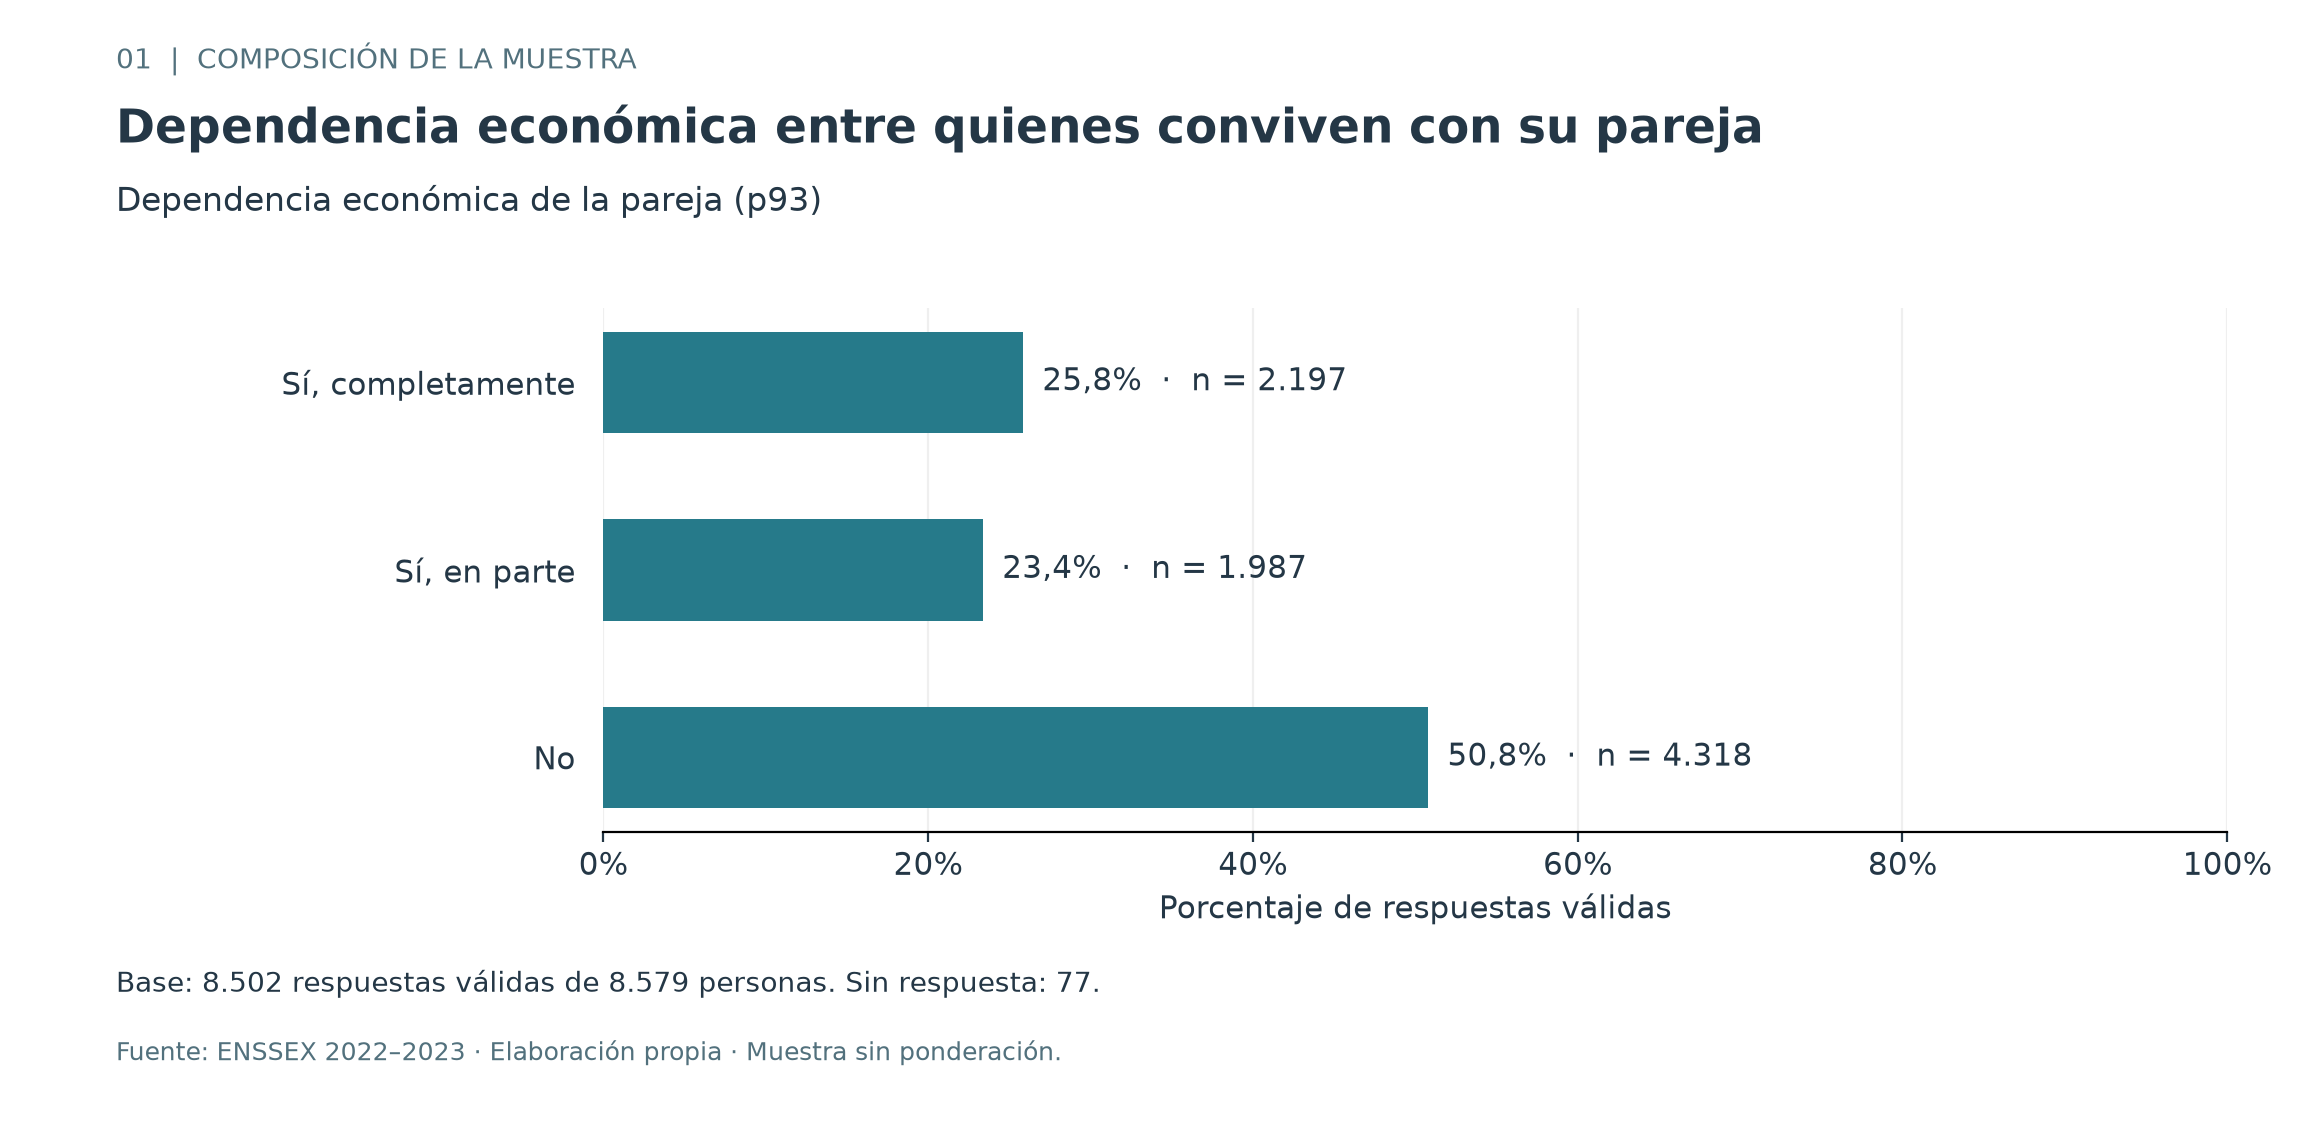

In [11]:
display(Image(filename=str(SALIDA_ANALISIS / 'figura_1_dependencia_economica.png'), width=1000))

### Figura 2. Valoración de la vida sexual (`i_6_p9`)

Responde a caracterizar y comparar esta dimensión según dependencia económica de la
pareja (`p93`). La respuesta 7 Muy bien reúne 38,43%, 33,98% y 38,16% en dependencia
completa, parcial y ninguna. La menor proporción con dependencia parcial se observa
también en ambos grupos de sexo asignado al nacer (`p1`): hombres 42,37%, 36,42% y
37,63%; mujeres 38,21%, 33,48% y 38,79%, en el mismo orden de dependencia.

No hay un aumento uniforme de esta respuesta al disminuir la dependencia. Los 118
hombres con dependencia completa y respuesta válida constituyen una base pequeña
respecto de los otros grupos; interpretamos su porcentaje junto con ese tamaño.
La respuesta máxima no sustituye la distribución completa de siete categorías.

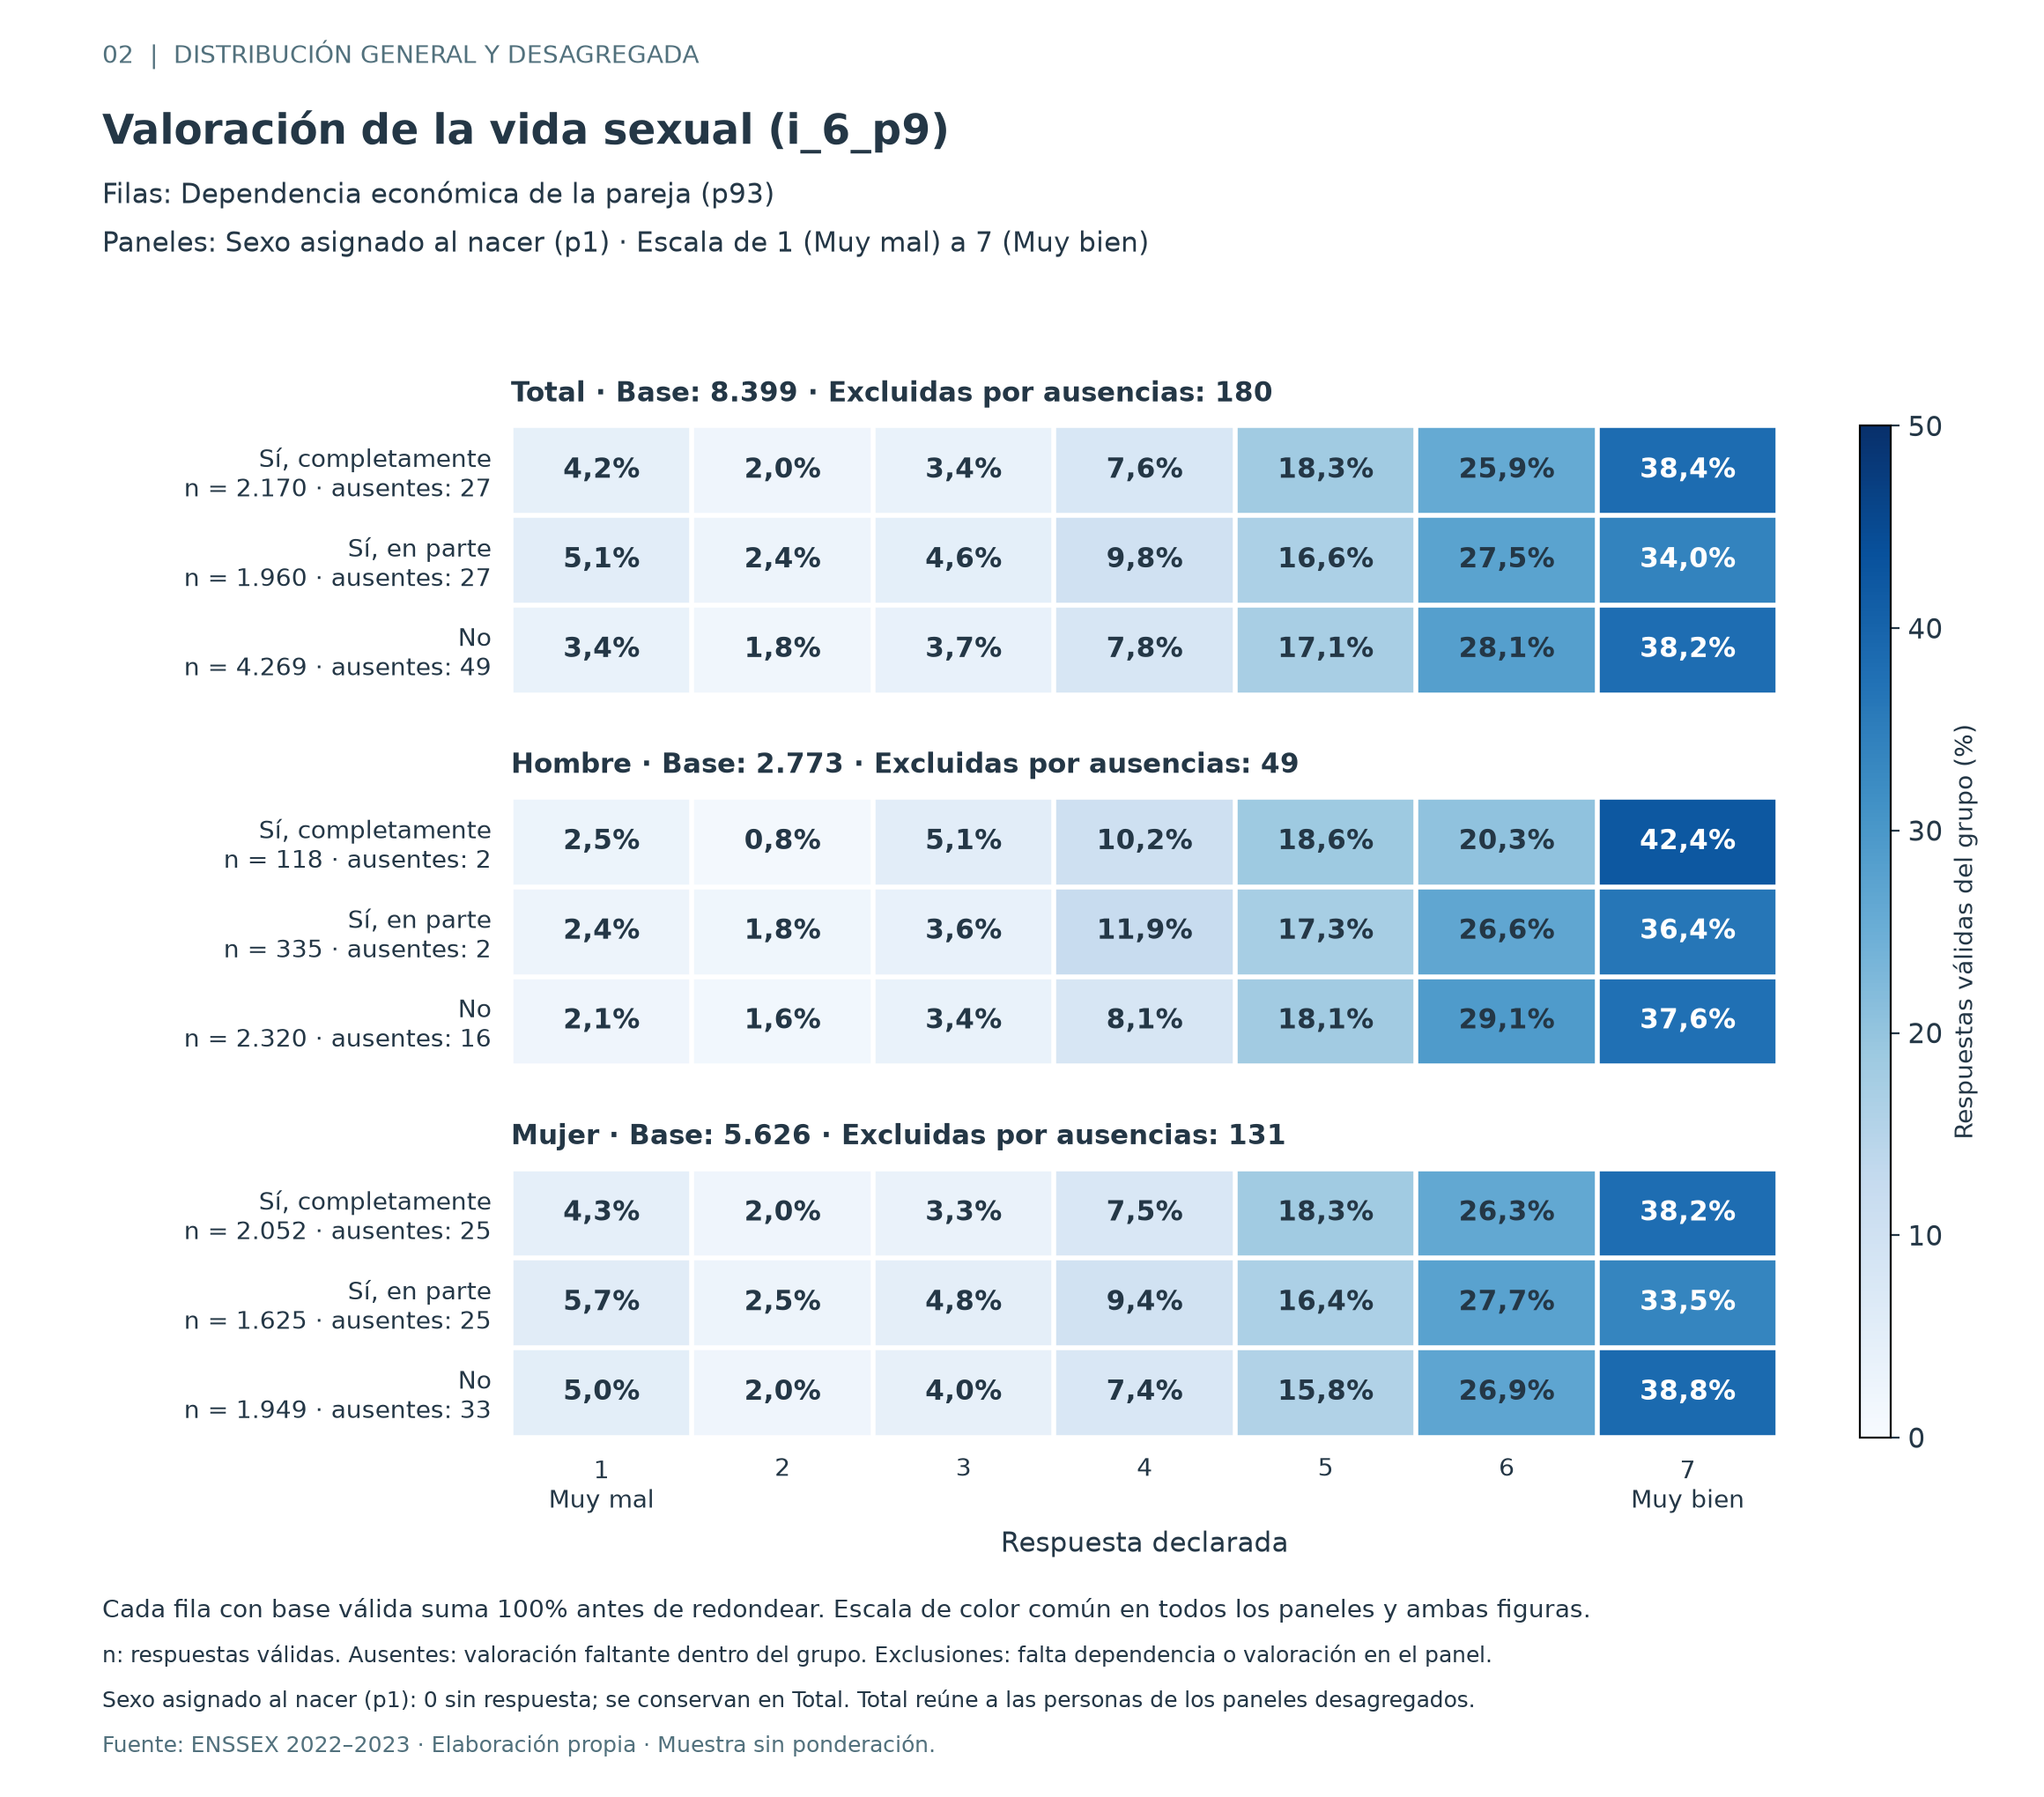

In [12]:
display(Image(filename=str(SALIDA_ANALISIS / 'figura_2_valoracion_vida_sexual.png'), width=1100))

### Figura 3. Bienestar mental o emocional percibido (`i_2_p9`)

Responde a caracterizar y comparar la segunda dimensión según dependencia económica
de la pareja (`p93`). En el total, quienes no dependen tienen mayores proporciones
de respuestas 6 (32,92%) y 7 (30,85%) que quienes dependen completa o parcialmente.
Entre los dos últimos grupos, el orden cambia según se observe la respuesta 6 o 7.

La desagregación por sexo asignado al nacer (`p1`) matiza ese resultado: en hombres,
la respuesta 7 representa 28,33%, 29,97% y 32,82% para dependencia completa, parcial y
ninguna; en mujeres, 29,41%, 26,86% y 28,53%. Por ello el patrón agregado no describe
igual a ambos grupos. Incluso en hombres, la respuesta 6 (35,00%, 31,16% y 34,53%)
no sigue un aumento uniforme. No resumimos toda la escala mediante una sola categoría.

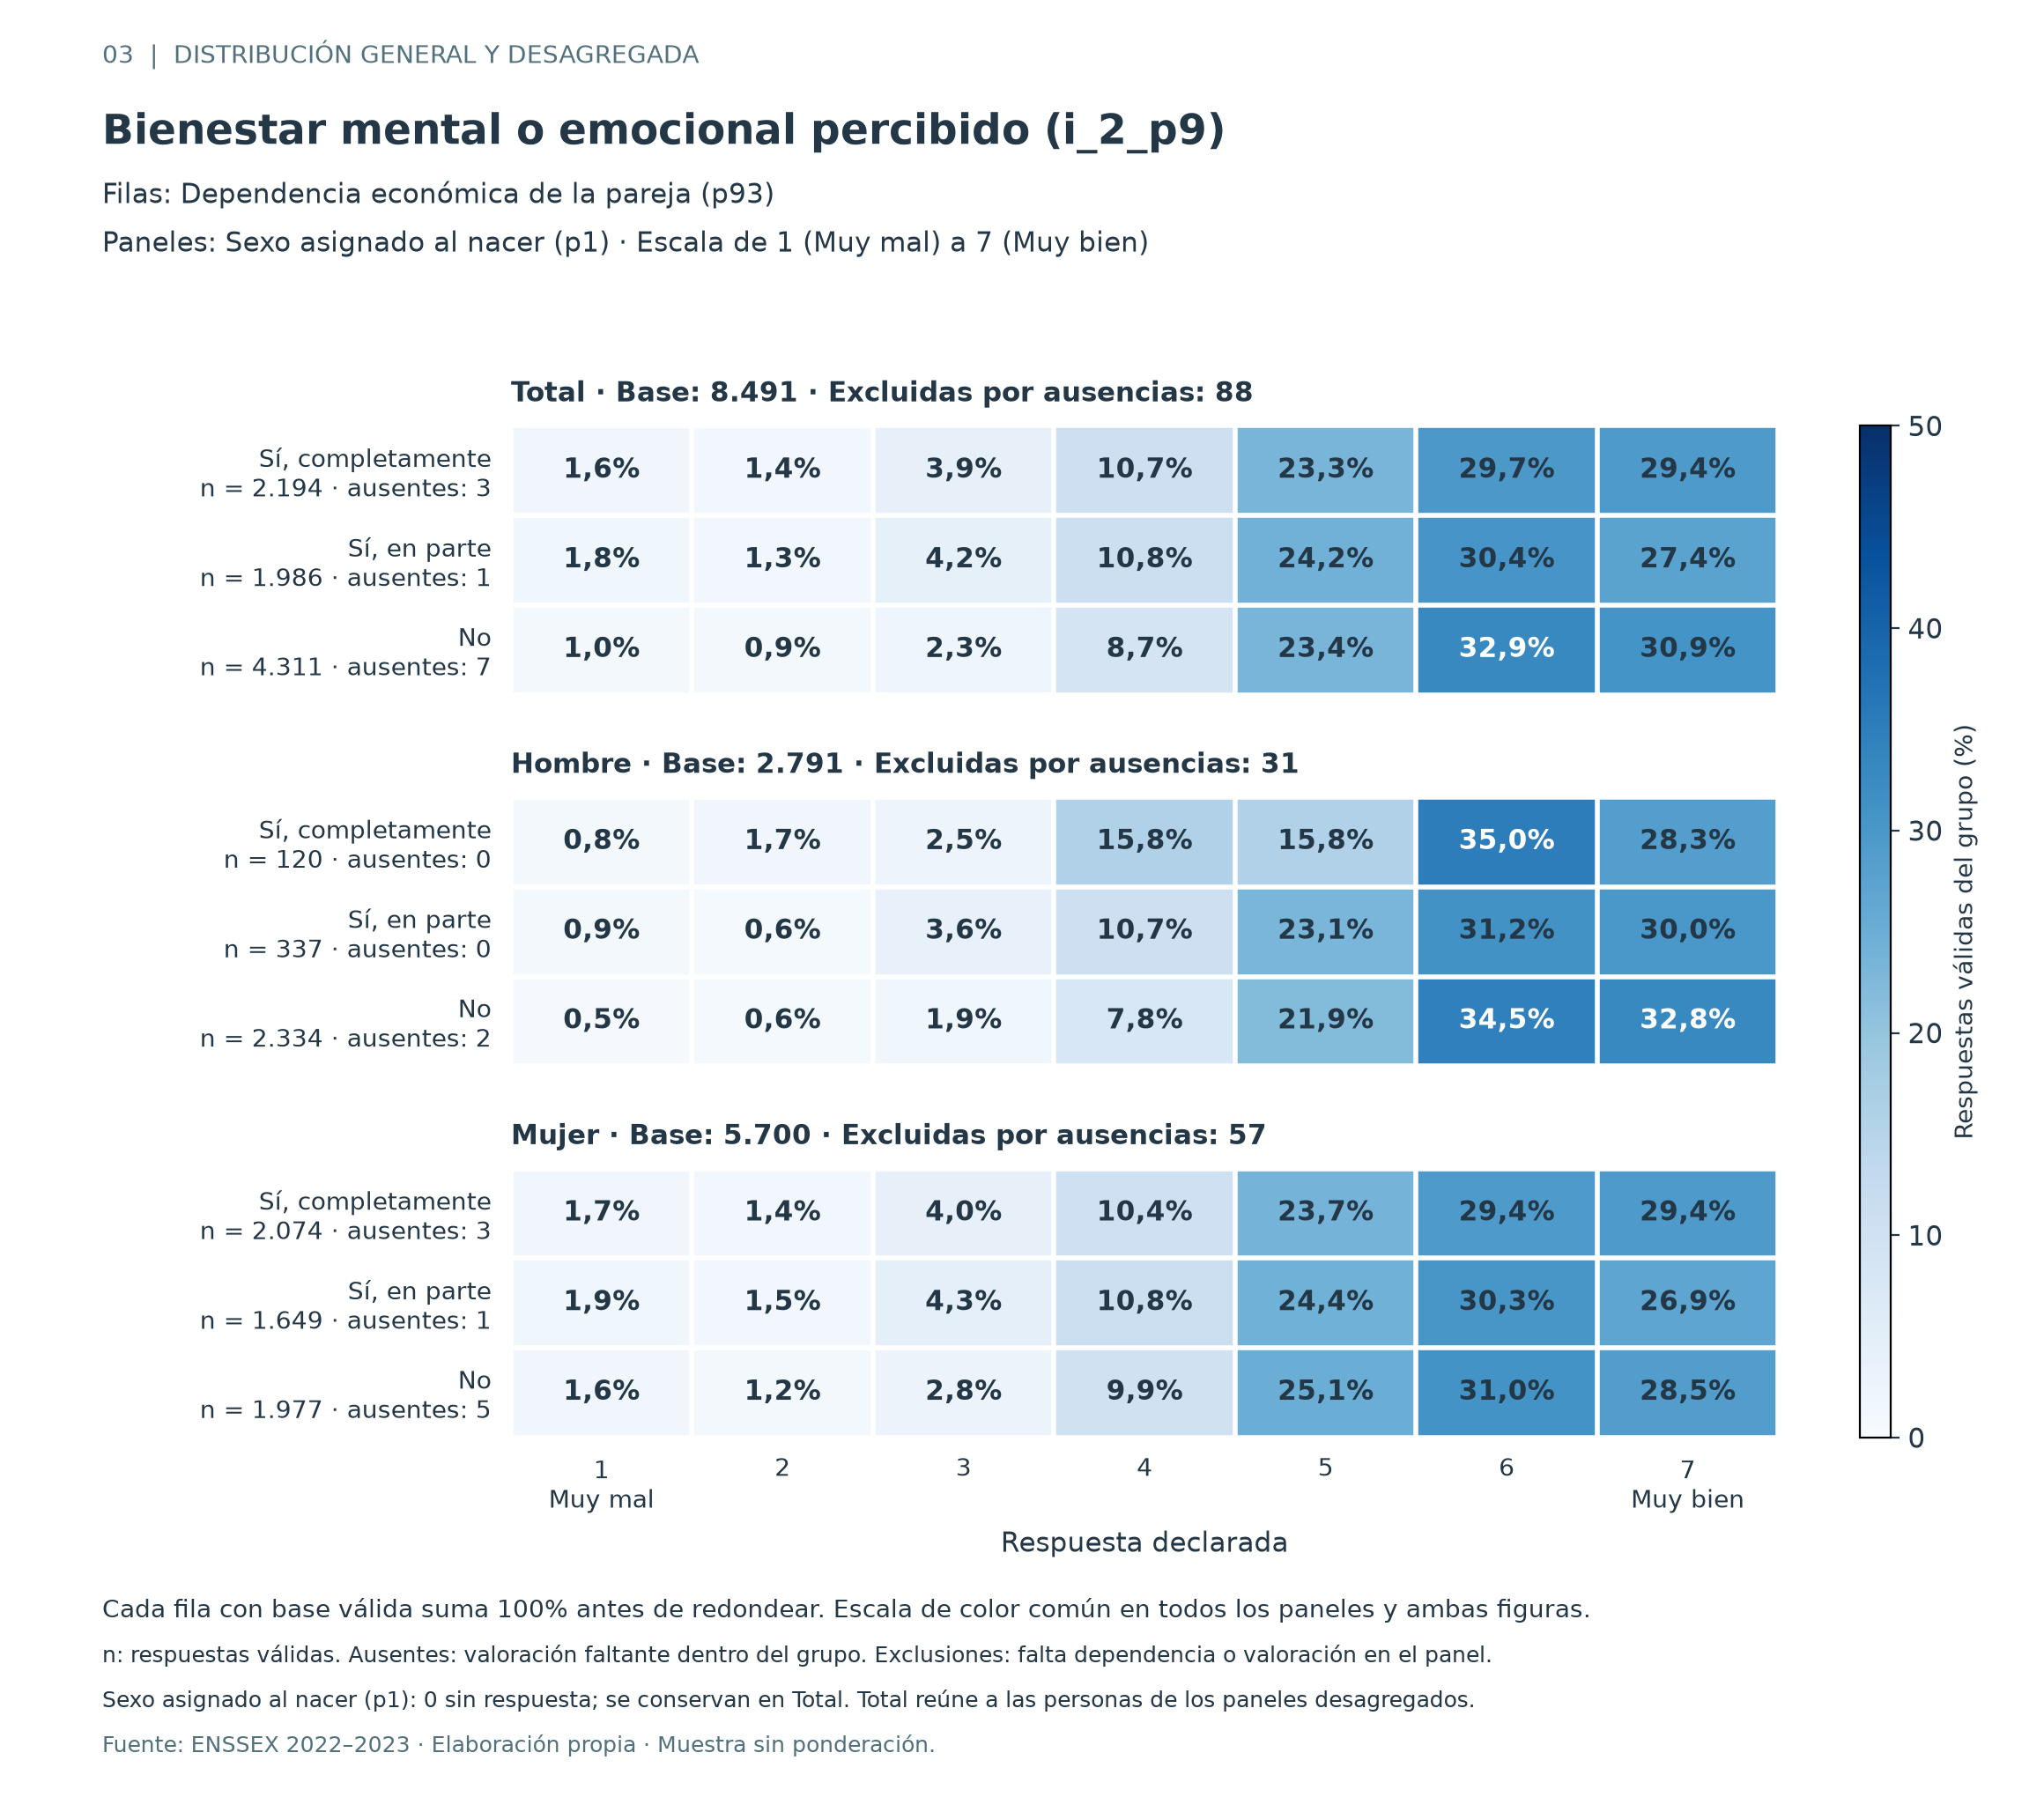

In [13]:
display(Image(filename=str(SALIDA_ANALISIS / 'figura_3_bienestar_mental_emocional.png'), width=1100))

<a id="cierre"></a>
## 7. Respuesta, discusión y conclusiones

**Respuesta a la pregunta:** en esta muestra, las valoraciones varían entre los
grupos de dependencia económica de la pareja (`p93`), pero no muestran una relación
uniforme en ambas dimensiones. En valoración de la vida sexual (`i_6_p9`), la
dependencia parcial presenta menor proporción de la respuesta máxima en el total y
en ambos sexos. En bienestar mental o emocional percibido (`i_2_p9`), el grupo sin
dependencia presenta mayores proporciones de respuestas 6 y 7 en el total, aunque
el patrón de respuesta 7 difiere por sexo asignado al nacer (`p1`).

Estos resultados cumplen los objetivos de describir, caracterizar y comparar;
no permiten afirmar que la dependencia cause las diferencias. La comparación
descriptiva no aísla edad, ingresos, género u otras características. Los tamaños
son desiguales, no calculamos incertidumbre y no suponemos ausencias aleatorias.
Los resultados sin ponderación no se extrapolan a la población de Chile; el bienestar
declarado es una percepción y no un diagnóstico clínico.

**Aprendizajes técnicos:** F2 estableció reglas explícitas y verificables; F3 las
organizó en clases sin cambiar los resultados; F4 recuperó categorías interpretables
y denominadores específicos para responder sustantivamente la pregunta. Separar
las mediciones de rendimiento del análisis evitó confundir mejoras de ejecución con
hallazgos sobre las personas. Conservar distribuciones y tamaños permitió detectar
matices que se perderían con un indicador combinado o una eliminación global de NA.

Como mejoras futuras, proponemos estudiar con mayor profundidad la composición
de los grupos y, si se amplía la pregunta, incorporar ponderación, diseño muestral
y un análisis ajustado debidamente justificado.

### Trazabilidad de cambios y revisión

| Antecedente | Mejora y evidencia | Impacto |
|---|---|---|
| F3 verificaba preparación, todavía sin respuesta sustantiva | PR #13, merge `bfa1c9a`: copia interpretable y relectura | Conservación de códigos, etiquetas y ausencias |
| Matriz nominal de 65 columnas inadecuada para estas figuras | PR #14, merge `3e6d5d6`: ocho tablas y tres figuras con categorías originales | Comunicación directa de las dos distribuciones |
| Necesidad de profundizar la comparación | PR #14: paneles por sexo asignado al nacer (`p1`) | Patrones internos y tamaños de grupo explícitos |
| Revisión cruzada antes de integrar | Karla ejecutó pruebas, generación, comparación de ocho tablas y revisión visual antes de aprobar PR #14 | Reproducción documentada en otro equipo |
| Integración de fases | Este cuaderno: fuente → F2 → clases F3 → resultados F4 | Flujo completo desde kernel nuevo |

La aprobación del PR #14 acredita sus módulos, tablas y figuras.

In [14]:
# Cierre verificable: protegemos originales, módulos y productos anteriores.
for relativa, huella in huellas_antes.items():
    assert prep.sha256_archivo(RAIZ / relativa) == huella, f'Archivo modificado: {relativa}'
pd.testing.assert_series_equal(pd.util.hash_pandas_object(base, index=True), huella_base)
pd.testing.assert_series_equal(base.dtypes, tipos_base)
pd.testing.assert_index_equal(base.columns, columnas_base)
for nombre, tabla in referencias_f2.items():
    pd.testing.assert_frame_equal(resultados_f3[nombre], tabla, check_exact=True)
assert all(p['codigo_salida'] == 0 for p in registros_pruebas)
assert len(comparacion_tablas) == 8
evidencia_ejecucion = {
    'inicio_utc': INICIO.isoformat(), 'fin_utc': datetime.now(timezone.utc).isoformat(),
    'base_integrada': '3e6d5d6', 'notebook': 'F4/notebooks/F4_Integrador_ENSSEX.ipynb',
    'entorno': entorno, 'carpeta_salida': SALIDA.relative_to(RAIZ).as_posix(),
    'fuente': {ruta_csv.name: fuente['csv_sha256'], ruta_sav.name: fuente['source_sha256']},
    'esquema_sha256_lf': prep.sha256_codigo(ruta_esquema),
    'codigo_sha256_lf': {p.relative_to(RAIZ).as_posix(): prep.sha256_codigo(p)
                         for p in protegidos if p.suffix == '.py'},
    'casos_f2': pruebas_f2.to_dict(orient='records'), 'pruebas_f3_f4': registros_pruebas,
    'medicion_edades': medicion_edades, 'medicion_sav': medicion_sav,
    'comparacion_tablas': comparacion_tablas, 'archivos_protegidos_intactos': True,
    'huellas_productos': {p.relative_to(SALIDA).as_posix(): prep.sha256_archivo(p)
                          for p in sorted(SALIDA.rglob('*')) if p.is_file()},
}
with (SALIDA / 'ejecucion_integrador.json').open('x', encoding='utf-8', newline='\n') as archivo:
    json.dump(evidencia_ejecucion, archivo, ensure_ascii=False, indent=2, allow_nan=False)
display(pd.DataFrame([
    {'Comprobación': 'Originales, módulos y productos previos intactos', 'Resultado': 'OK'},
    {'Comprobación': 'F2 y F3 equivalentes; 130 invariantes', 'Resultado': 'OK'},
    {'Comprobación': 'Casos F2 y nueve scripts F3–F4', 'Resultado': 'OK'},
    {'Comprobación': 'Exportaciones F3 y F4: relectura exacta', 'Resultado': 'OK'},
    {'Comprobación': 'Ocho tablas reproducidas y tres figuras generadas', 'Resultado': 'OK'},
]))
print('Evidencia local:', (SALIDA / 'ejecucion_integrador.json').relative_to(RAIZ).as_posix())
print('OK: flujo F1–F4 completado. Guardar el notebook para conservar estas salidas.')

,Comprobación,Resultado
0,"Originales, módulos y productos previos intactos",OK
1,F2 y F3 equivalentes; 130 invariantes,OK
2,Casos F2 y nueve scripts F3–F4,OK
3,Exportaciones F3 y F4: relectura exacta,OK
4,Ocho tablas reproducidas y tres figuras generadas,OK


Evidencia local: F4/resultados_locales/notebook_20261002_221705_086f70ef/ejecucion_integrador.json
OK: flujo F1–F4 completado. Guardar el notebook para conservar estas salidas.


### Fuentes y documentación del proyecto

La procedencia, el cuestionario y el manual de ENSSEX están documentados en la
[guía de fuente](../../docs/datos/Obtencion_y_conversion_ENSSEX.md) y en el
[notebook F1](../../F1/notebooks/F1_Definicion.ipynb). Las reglas aplicadas y etiquetas
corresponden al [esquema F2](../../F2/docs/esquema_variables_F2.json).

- [Decisiones F1–F2](../../F2/docs/Bitacora_decisiones_F1_F2.md).
- [Arquitectura y POO](../../F3/docs/Pipeline_ENSSEX.md).
- [Tratamiento de faltantes](../../F3/docs/Tratamiento_faltantes.md).
- [Complejidad y mediciones de la diferencia de edad](../../F3/docs/Complejidad_diferencia_edad.md).
- [Medición de lectura SAV](../../F3/docs/Medicion_lectura_SAV.md).
- [Resultados descriptivos completos](../docs/Resultados_descriptivos.md).
- [PR #13](https://github.com/gosoriozamora/mcdi500-grupo9-enssex/pull/13) y
  [PR #14](https://github.com/gosoriozamora/mcdi500-grupo9-enssex/pull/14): ejecución, comentarios e integración.

Los notebooks de fases previas conservan su contexto histórico; este cuaderno
integra las decisiones vigentes. El informe final deberá mantener estas cifras,
denominadores y límites, junto con las referencias bibliográficas de la entrega.